# Evaluation of Root Heights

In [1]:
from Bio import Nexus, Phylo, SeqIO
from collections import defaultdict
from io import StringIO

import matplotlib.pyplot as plt
from matplotlib import gridspec

import seaborn as sns

import pandas as pd
import numpy as np

import re
from pathlib import Path

from itertools import combinations

from evaluation_helpers import *

In [2]:
tree_metrics_combined = load_node_errors("../results/run1/evaluation")
root_height_df_wide = tree_metrics_combined[tree_metrics_combined['node_id'] == "internal_0"]
root_height_df_wide.to_csv("../results/run1/evaluation/root_height_info.csv", sep= "\t", index = False)

/Users/mariebecker/Documents/Uni/ETH/RotationStadler/BESP_paper-analyses/workflows/evaluation_helpers.py:3810: DtypeWarning: Columns (50,94) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(tsv, sep="\t"))
/Users/mariebecker/Documents/Uni/ETH/RotationStadler/BESP_paper-analyses/workflows/evaluation_helpers.py:3810: DtypeWarning: Columns (50,94) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(tsv, sep="\t"))
/Users/mariebecker/Documents/Uni/ETH/RotationStadler/BESP_paper-analyses/workflows/evaluation_helpers.py:3810: DtypeWarning: Columns (50,94) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(tsv, sep="\t"))
/Users/mariebecker/Documents/Uni/ETH/RotationStadler/BESP_paper-analyses/workflows/evaluation_helpers.py:3810: DtypeWarning: Columns (50,94) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.r

In [3]:
root_height_df_wide = pd.read_csv("../results/run1/evaluation/root_height_info.csv", sep= "\t")
root_height_df_wide

,tree_index,node_idx,node_id,internal,height_sim,bl_sim,constcoal_pop_diff_median,constcoal_pop_diff_hpd_lower,constcoal_pop_diff_hpd_upper,constcoal_pop_rel_error_median,...,skyline_height_est_hpd_lower,skyline_height_est_hpd_upper,skyline_bl_est_median,skyline_bl_est_hpd_lower,skyline_bl_est_hpd_upper,skyline_height_inside_ci,skyline_bl_inside_ci,sampling,population_model,mutation_signal
0,0,0,internal_0,True,2995.021345,0.0,-127.088000,-236.003536,-6.320547,-0.127088,...,4080.487948,4440.618703,NaN,NaN,NaN,False,NaN,independenthomochronous,bottleneck,high
1,1,0,internal_0,True,1797.360469,0.0,-154.919397,-258.509556,-44.732510,-0.154919,...,1922.481100,2087.252494,NaN,NaN,NaN,False,NaN,independenthomochronous,bottleneck,high
2,2,0,internal_0,True,3492.044982,0.0,-222.825124,-322.426036,-109.869521,-0.222825,...,5142.319345,5588.547079,NaN,NaN,NaN,False,NaN,independenthomochronous,bottleneck,high
3,3,0,internal_0,True,1312.193877,0.0,-36.616512,-148.634362,103.990956,-0.036617,...,1375.176615,1538.215136,NaN,NaN,NaN,False,NaN,independenthomochronous,bottleneck,high
4,4,0,internal_0,True,1743.065750,0.0,-189.882196,-281.729422,-63.797783,-0.189882,...,2030.322342,2236.236307,NaN,NaN,NaN,False,NaN,independenthomochronous,bottleneck,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2124,95,0,internal_0,True,2100.358660,0.0,40.931492,-83.267563,166.460761,0.040931,...,2183.172762,2461.296638,NaN,NaN,NaN,False,NaN,linearconstant,uniform,med
2125,96,0,internal_0,True,2904.746105,0.0,104.831089,-36.410755,253.747703,0.104831,...,3219.055021,3527.348675,NaN,NaN,NaN,False,NaN,linearconstant,uniform,med
2126,97,0,internal_0,True,4322.027642,0.0,88.866461,-49.887069,220.425725,0.088866,...,5426.885504,5987.801666,NaN,NaN,NaN,False,NaN,linearconstant,uniform,med
2127,98,0,internal_0,True,10935.968474,0.0,280.935944,135.350787,472.927482,0.280936,...,19661.427908,21335.345669,NaN,NaN,NaN,False,NaN,linearconstant,uniform,med


In [9]:
tree_metrics_combined

,tree_index,node_idx,node_id,internal,height_sim,bl_sim,constcoal_pop_diff_median,constcoal_pop_diff_hpd_lower,constcoal_pop_diff_hpd_upper,constcoal_pop_rel_error_median,...,skyline_height_est_hpd_lower,skyline_height_est_hpd_upper,skyline_bl_est_median,skyline_bl_est_hpd_lower,skyline_bl_est_hpd_upper,skyline_height_inside_ci,skyline_bl_inside_ci,sampling,population_model,mutation_signal
0,0,0,internal_0,True,2995.021345,0.000000,-127.08800,-236.003536,-6.320547,-0.127088,...,4080.487948,4440.618703,NaN,NaN,NaN,False,NaN,independenthomochronous,bottleneck,high
1,0,1,internal_1,True,384.602997,2610.418348,-127.08800,-236.003536,-6.320547,-0.127088,...,384.188333,443.722829,3844.917564,3661.470533,4022.880434,True,False,independenthomochronous,bottleneck,high
2,0,2,internal_2,True,383.386132,1.216865,-127.08800,-236.003536,-6.320547,-0.127088,...,383.422421,442.594432,1.859164,0.001513,9.116270,False,True,independenthomochronous,bottleneck,high
3,0,3,internal_3,True,203.556381,179.829752,-127.08800,-236.003536,-6.320547,-0.127088,...,184.964357,220.425400,208.174827,179.329131,238.972310,True,True,independenthomochronous,bottleneck,high
4,0,4,internal_4,True,176.494239,27.062142,-127.08800,-236.003536,-6.320547,-0.127088,...,158.018268,187.384435,30.997203,17.927611,46.519036,True,True,independenthomochronous,bottleneck,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1061704,99,504,internal_504,True,132.019622,320.990271,-97.84427,-228.342079,9.808144,-0.097844,...,113.736127,144.790521,316.363396,280.284196,362.554453,True,True,linearconstant,uniform,med
1061705,99,505,internal_505,True,93.787410,38.232212,-97.84427,-228.342079,9.808144,-0.097844,...,93.467467,98.573944,31.496584,15.746469,47.270371,True,True,linearconstant,uniform,med
1061706,99,506,tip_506,False,76.148019,17.639391,-97.84427,-228.342079,9.808144,-0.097844,...,NaN,NaN,18.495213,17.319467,22.425944,NaN,True,linearconstant,uniform,med
1061707,99,507,tip_507,False,93.467058,0.320352,-97.84427,-228.342079,9.808144,-0.097844,...,NaN,NaN,1.176113,0.000367,5.106844,NaN,True,linearconstant,uniform,med


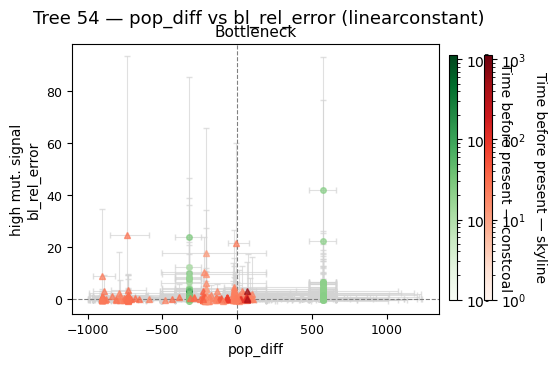

In [ ]:
# check how big the errors are for one tree 

df_long = melt_node_errors(tree_metrics_combined, metrics=["pop_diff", "bl_rel_error"])

plot_single_tree_errors(
    df_long,                                                                                                                                                                               
    sampling="linearconstant",
    tree_index=54,
    x_col="pop_diff",
    y_col="bl_rel_error",
    pop_models=["bottleneck"],
    mutsigs=["high"],
)

In [21]:
tree_metrics_combined[(tree_metrics_combined["tree_index"] == 54) & (tree_metrics_combined["population_model"] == "bottleneck") & (tree_metrics_combined["mutation_signal"] == "high") & (tree_metrics_combined["sampling"] == "linearconstant")]['constcoal_bl_rel_error_median'].describe()

count    472.000000
mean       0.604488
std        2.793723
min       -0.749615
25%       -0.151882
50%        0.033685
75%        0.307473
max       41.773919
Name: constcoal_bl_rel_error_median, dtype: float64

In [16]:
tree_metrics_combined_short['constcoal_bl_rel_error_median'].describe()

count    472.000000
mean       0.596694
std        2.694518
min       -0.755699
25%       -0.153386
50%        0.031300
75%        0.313383
max       39.564476
Name: constcoal_bl_rel_error_median, dtype: float64

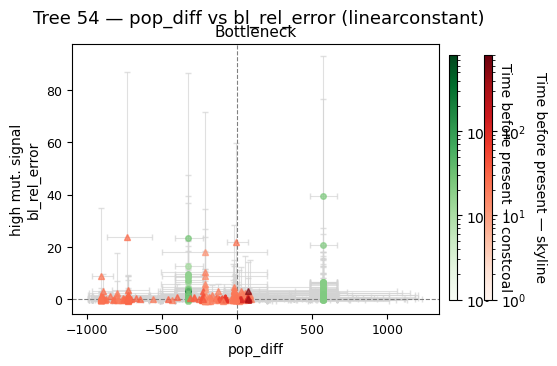

In [9]:
tree_metrics_combined_short = load_node_errors("../results/run1/evaluation_t54_full_test")

df_long_short = melt_node_errors(tree_metrics_combined_short, metrics=["pop_diff", "bl_rel_error"])

plot_single_tree_errors(
    df_long_short,                                                                                                                                                                               
    sampling="linearconstant",
    tree_index=54,
    x_col="pop_diff",
    y_col="bl_rel_error",
    pop_models=["bottleneck"],
    mutsigs=["high"],
)

count    472.000000
mean       0.986853
std        0.031047
min        0.898499
25%        0.964633
50%        0.986861
75%        1.008611
max        1.094727
dtype: float64
count    472.000000
mean       0.007795
std        0.135886
min       -0.399308
25%       -0.008227
50%        0.000034
75%        0.007202
max        2.209443
dtype: float64
count    472.000000
mean       0.989196
std        0.033623
min        0.870713
25%        0.968694
50%        0.988582
75%        1.008049
max        1.110446
dtype: float64
count    472.000000
mean       0.002954
std        0.067073
min       -0.342426
25%       -0.007703
50%        0.000413
75%        0.007253
max        0.933599
dtype: float64


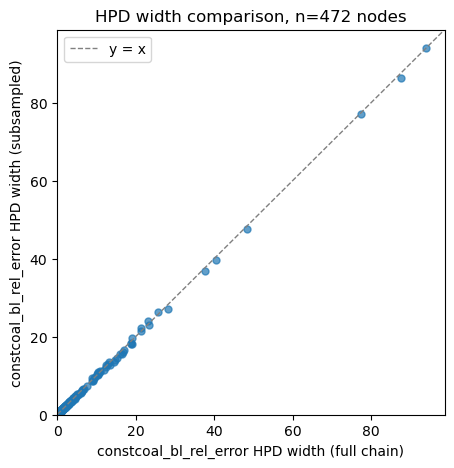

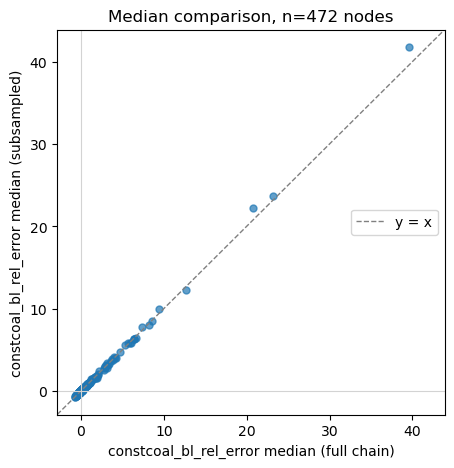

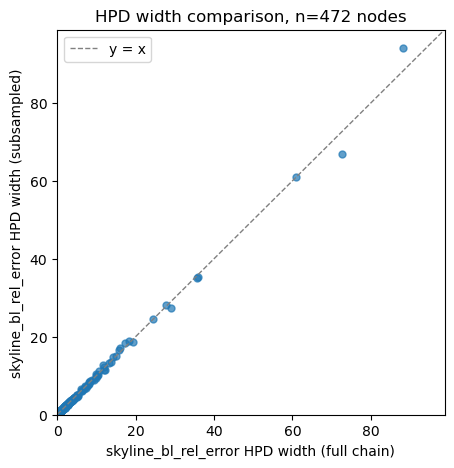

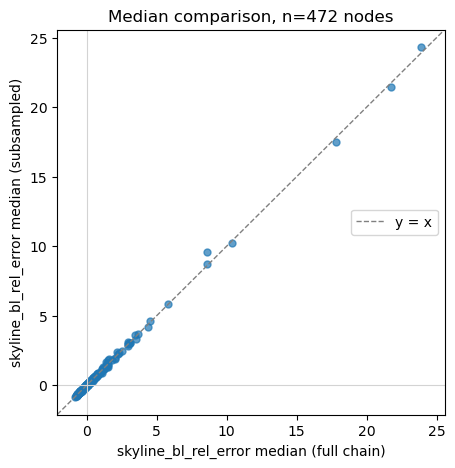

In [26]:
import matplotlib.pyplot as plt

def plot_hpd_width_comparison(df_sub, df_full, error_col, merge_key="node_idx", ax=None):
    """
    Scatter plot comparing HPD widths for `error_col` between two node-error
    dataframes (e.g. subsampled vs. full-chain), already filtered to the
    same single tree/replicate. One point per node.

    Parameters
    ----------
    df_sub, df_full : pd.DataFrame
        node_errors-style dataframes, filtered to one tree_index each.
    error_col : str
        Full metric column prefix, e.g. "constcoal_bl_rel_error" or
        "skyline_pop_diff" (i.e. without the _median/_hpd_lower/_hpd_upper suffix).
    merge_key : str
        Column to match nodes on between the two dataframes (default "node_idx").
    ax : matplotlib Axes, optional
    """
    lo, hi = f"{error_col}_hpd_lower", f"{error_col}_hpd_upper"

    a = df_sub[[merge_key, lo, hi]].rename(columns={lo: "lo_sub", hi: "hi_sub"})
    b = df_full[[merge_key, lo, hi]].rename(columns={lo: "lo_full", hi: "hi_full"})
    m = a.merge(b, on=merge_key).dropna()

    m["width_sub"]  = m["hi_sub"]  - m["lo_sub"]
    m["width_full"] = m["hi_full"] - m["lo_full"]

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    ax.scatter(m["width_full"], m["width_sub"], alpha=0.7, s=25)
    lims = [0, max(m["width_full"].max(), m["width_sub"].max()) * 1.05]
    ax.plot(lims, lims, "--", color="gray", linewidth=1, label="y = x")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f"{error_col} HPD width (full chain)")
    ax.set_ylabel(f"{error_col} HPD width (subsampled)")
    ax.set_title(f"HPD width comparison, n={len(m)} nodes")
    ax.legend()

    ratio = m["width_sub"] / m["width_full"]
    print(ratio.describe())

    return m

def plot_median_comparison(df_sub, df_full, error_col, merge_key="node_idx", ax=None):
    """
    Scatter plot comparing point-estimate medians for `error_col` between two
    node-error dataframes (e.g. subsampled vs. full-chain), already filtered
    to the same single tree/replicate. One point per node.                                                                                                                                 

    Parameters
    ----------                                                                                                                                                                             
    df_sub, df_full : pd.DataFrame
        node_errors-style dataframes, filtered to one tree_index each.
    error_col : str
        Full metric column prefix, e.g. "constcoal_bl_rel_error" or
        "skyline_pop_diff" (i.e. without the _median suffix).
    merge_key : str
        Column to match nodes on between the two dataframes (default "node_idx").
    ax : matplotlib Axes, optional
    """
    med = f"{error_col}_median"                                                                                                                                                            

    a = df_sub[[merge_key, med]].rename(columns={med: "median_sub"})
    b = df_full[[merge_key, med]].rename(columns={med: "median_full"})
    m = a.merge(b, on=merge_key).dropna()

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    ax.scatter(m["median_full"], m["median_sub"], alpha=0.7, s=25)
    lo = min(m["median_full"].min(), m["median_sub"].min())
    hi = max(m["median_full"].max(), m["median_sub"].max())
    pad = (hi - lo) * 0.05 if hi > lo else 1
    lims = [lo - pad, hi + pad]
    ax.plot(lims, lims, "--", color="gray", linewidth=1, label="y = x")
    ax.axhline(0, color="lightgray", linewidth=0.8)
    ax.axvline(0, color="lightgray", linewidth=0.8)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f"{error_col} median (full chain)")
    ax.set_ylabel(f"{error_col} median (subsampled)")
    ax.set_title(f"Median comparison, n={len(m)} nodes")
    ax.legend()

    diff = m["median_sub"] - m["median_full"]
    print(diff.describe())

    return m

df_sub  = tree_metrics_combined[(tree_metrics_combined["tree_index"] == 54) &
                                   (tree_metrics_combined["population_model"] == "bottleneck") &
                                   (tree_metrics_combined["mutation_signal"] == "high") &
                                   (tree_metrics_combined["sampling"] == "linearconstant")]
df_full = tree_metrics_combined_short   # your full-chain result for the same tree
  
m = plot_hpd_width_comparison(df_sub, df_full, error_col="constcoal_bl_rel_error")
m = plot_median_comparison(df_sub, df_full, error_col="constcoal_bl_rel_error")
m = plot_hpd_width_comparison(df_sub, df_full, error_col="skyline_bl_rel_error")
m = plot_median_comparison(df_sub, df_full, error_col="skyline_bl_rel_error")

In [ ]:
Submitting: linearconstant/expgrowthfast/low
Submitted batch job 13706813
Submitting: linearconstant/expgrowthfast/med
Submitted batch job 13706815
Submitting: linearconstant/expgrowthfast/high
Submitted batch job 13706816
Submitting: linearconstant/expgrowthslow/low
Submitted batch job 13706817
Submitting: linearconstant/expgrowthslow/med
Submitted batch job 13706818
Submitting: linearconstant/expgrowthslow/high
Submitted batch job 13706819
Submitting: linearconstant/uniform/low
Submitted batch job 13706820
Submitting: linearconstant/uniform/med
Submitted batch job 13706821
Submitting: linearconstant/uniform/high
Submitted batch job 13706822
Submitting: linearconstant/bottleneck/low
Submitted batch job 13706823
Submitting: linearconstant/bottleneck/med
Submitted batch job 13706824
Submitting: linearconstant/bottleneck/high
Submitted batch job 13706826
(base) b

In [ ]:
mkdir -p logs results/run1/evaluation_timebins_full_test
sbatch --job-name=timebins_full_test --time=96:00:00 --mem-per-cpu=300000 --cpus-per-task=1 \
--output=logs/timebins_full_test_%j.out \
--wrap="conda run -n beast_tools python -u scripts/compute_time_bins.py \
--tsv results/run1/evaluation/linearconstant/bottleneck/low.tsv \
--out_dir results/run1/evaluation_timebins_full_test \
--config 1,50 \
--log_suffix combined \
--trees_suffix combined" 


# send as 13346552

In [ ]:
sbatch --job-name=timebins_rate_test --time=08:00:00 --mem-per-cpu=64000 --cpus-per-task=1 \
--output=logs/timebins_rate_test_%j.out \
--wrap="conda run -n beast_tools python -u scripts/compute_time_bins.py \
--tsv results/run1/evaluation/linearconstant/bottleneck/high.tsv \
--out_dir results/run1/evaluation_timebins_full_test \
--config 1,50 \
--max_reps 10 \
--log_suffix combined \                                                                                                                                                            
--trees_suffix combined"

In [7]:
import pandas as pd
df = pd.read_csv("../results/run1/evaluation/linearconstant/bottleneck/high.tsv", sep="\t")
df[df["tree_index"] == 54].to_csv("../results/run1/evaluation/linearconstant/bottleneck/t54_only.tsv", sep="\t", index=False)

In [ ]:
# test whether running the error compuatation without subsampling gives shorter hpds in the error calculations

sbatch --job-name=t54_full_test --time=8:00:00 --mem-per-cpu=64000 --cpus-per-task=1 \
--output=logs/t54_full_test_%j.out \
--wrap="conda run -n beast_tools python -u scripts/compute_errors.py \
--tsv results/run1/evaluation/linearconstant/bottleneck/t54_only.tsv \
--out_dir results/run1/evaluation_t54_full_test \
--traj_points 1000 \
--log_suffix combined \
--trees_suffix combined"

## CI overlap

1.  How much do the constcoal and skyline posterior distributions of root height overlap with each other, per condition.
    - Evaluating the overlap (by assuming a normal distribution of the posterior, since I only have the 95% HPD borders and not the full posterior) shows that the higher the mutation signal, the higher is the overlap between the CIs
    - low mutation signal exponentials have quite low overlap between the confidence intervals

2. How oftern do skyline and constcoal cases get confidence intervals that fit the true root height?
    - bottleneck and uniform tend to be overconfident, especially for high mutation signal were root is very far in the past, heterochronous sampling performs better than homochronous
    - for expgrowth we see that the skyline is a lot better to capture the true uncertainty (especially for low mut. sig.)

In [4]:
display(evaluate_ci_overlap(root_height_df_wide, sampling="linearconstant"))
evaluate_ci_overlap(root_height_df_wide, sampling="independenthomochronous")

population_model  mutation_signal
uniform           high               0.977183
                  med                0.976694
                  low                0.961220
expgrowthslow     high               0.889542
                  med                0.829447
                  low                0.635457
expgrowthfast     high               0.811173
                  med                0.730337
                  low                0.468880
bottleneck        high               0.954558
                  med                0.953488
                  low                0.932448
Name: overlap, dtype: float64

population_model  mutation_signal
uniform           high               0.980634
                  med                0.979898
                  low                0.960946
expgrowthslow     high               0.891822
                  med                0.845931
                  low                0.673121
expgrowthfast     high               0.826068
                  med                0.741434
                  low                0.485431
bottleneck        high               0.979177
                  med                0.976570
                  low                0.975858
Name: overlap, dtype: float64

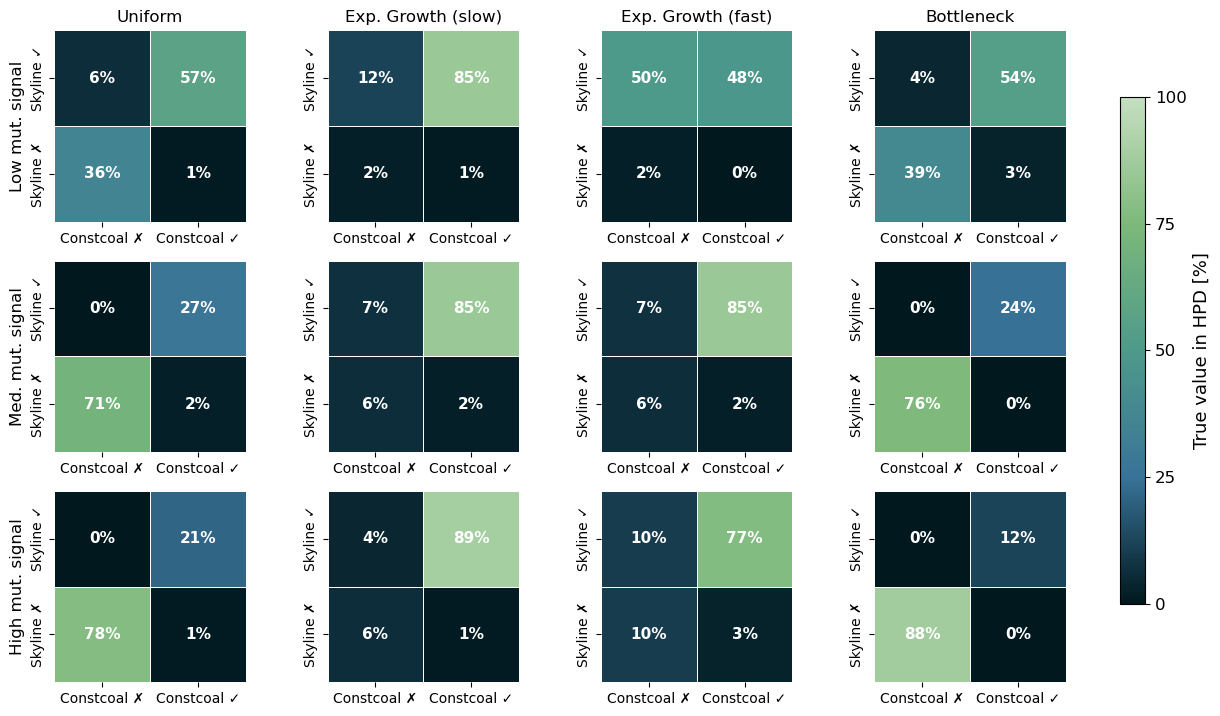

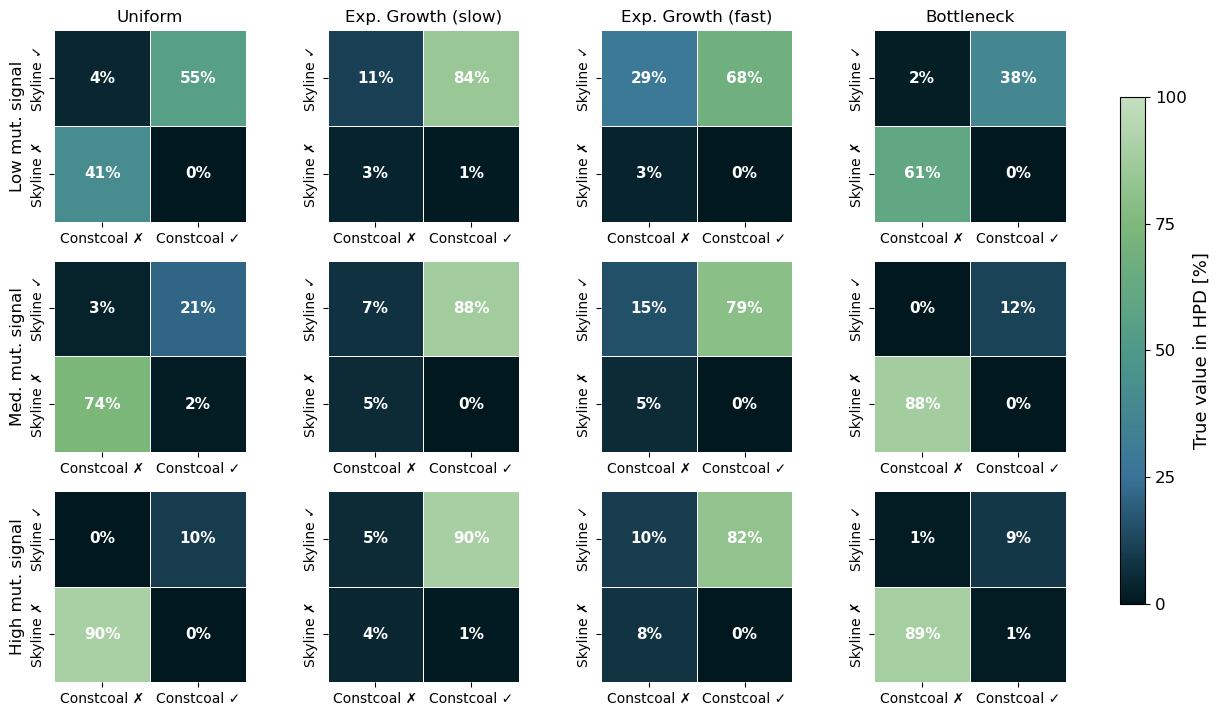

In [5]:
plot_ci_coverage_heatmap(root_height_df_wide, sampling = 'linearconstant', title = "", save_path= "../figures/root_height/hpd_coverage_heatmap_linearconstant.pdf", cbar_label = "True value in HPD [%]")
plot_ci_coverage_heatmap(root_height_df_wide, sampling = 'independenthomochronous', title = "", save_path= "../figures/root_height/hpd_coverage_heatmap_independenthomochronous.pdf", cbar_label = "True value in HPD [%]")

In [ ]:
cd /cluster/work/stadler/beckermar/BESP_paper-analyses/results/run1/single_tree_full_chain_test/uniform/high

sbatch --job-name=beast_nomutsig --time=04:00:00 --mem-per-cpu=1000 --cpus-per-task=2 \
--output=beast_nomutsig_%j.out \
--wrap="source /etc/profile && module load stack/2024-06 openjdk/21.0.3_9 gcc/12.2.0 beast1/1.10.4 libbeagle/3.1.2 && beast -overwrite -seed 44 constcoal_linearconstant_uniform_nomutsig.T86.xml"

sbatch --job-name=beast_nomutsig_fixedpop --time=04:00:00 --mem-per-cpu=1000 --cpus-per-task=2 \
--output=beast_nomutsig_fixedpopsize_%j.out \
--wrap="source /etc/profile && module load stack/2024-06 openjdk/21.0.3_9 gcc/12.2.0 beast1/1.10.4 libbeagle/3.1.2 && beast -overwrite -seed 44 constcoal_linearconstant_uniform_nomutsig_fixedpopsize.T86.xml"


In [6]:
print("Percentage of root height estimates inside 95% HPD by condition and model:")
display(root_height_df_wide.groupby(['population_model', 'mutation_signal', 'sampling']).apply(                                                                                                               
    lambda g: pd.Series({
        "constcoal": g["constcoal_height_inside_ci"].mean(),
        "skyline":   g["skyline_height_inside_ci"].mean(),
    }), include_groups=False
).reset_index())

Percentage of root height estimates inside 95% HPD by condition and model:


,population_model,mutation_signal,sampling,constcoal,skyline
0,bottleneck,high,independenthomochronous,0.100000,0.100000
1,bottleneck,high,linearconstant,0.123711,0.123711
2,bottleneck,low,independenthomochronous,0.375000,0.392857
3,bottleneck,low,linearconstant,0.563380,0.577465
4,bottleneck,med,independenthomochronous,0.118421,0.118421
5,bottleneck,med,linearconstant,0.244681,0.244681
6,expgrowthfast,high,independenthomochronous,0.824176,0.923077
7,expgrowthfast,high,linearconstant,0.800000,0.870000
8,expgrowthfast,low,independenthomochronous,0.681319,0.967033
9,expgrowthfast,low,linearconstant,0.479592,0.979592


## Scatter plot showing error in root height depending on cumulative error in population size

Observations:
- uniform and bottleneck are overconfident, especially for high mut. signal
- for exponentialgrowth, constant coalescent has higher error in rate and also higher error in root height
- we see this effect both for relative and absolute errors which shows that for skyline errors not just cancel each other out
- both heterochronous and homochronous sampling show the same trend but heterochronous sampling is a little bit more clear

In [29]:
root_height_df_wide.columns

Index(['tree_index', 'node_idx', 'node_id', 'internal', 'height_sim', 'bl_sim',
       'constcoal_pop_diff_median', 'constcoal_pop_diff_hpd_lower',
       'constcoal_pop_diff_hpd_upper', 'constcoal_pop_rel_error_median',
       'constcoal_pop_rel_error_hpd_lower',
       'constcoal_pop_rel_error_hpd_upper',
       'constcoal_pop_abs_rel_error_median',
       'constcoal_pop_abs_rel_error_hpd_lower',
       'constcoal_pop_abs_rel_error_hpd_upper', 'constcoal_rate_diff_median',
       'constcoal_rate_diff_hpd_lower', 'constcoal_rate_diff_hpd_upper',
       'constcoal_rate_rel_error_median', 'constcoal_rate_rel_error_hpd_lower',
       'constcoal_rate_rel_error_hpd_upper',
       'constcoal_rate_abs_rel_error_median',
       'constcoal_rate_abs_rel_error_hpd_lower',
       'constcoal_rate_abs_rel_error_hpd_upper',
       'constcoal_height_diff_median', 'constcoal_height_diff_hpd_lower',
       'constcoal_height_diff_hpd_upper', 'constcoal_height_rel_error_median',
       'constcoal_height_

In [36]:
root_height_df_wide[(root_height_df_wide["sampling"] == "linearconstant") & (root_height_df_wide["population_model"] == "uniform") & (root_height_df_wide["mutation_signal"] == "low")].sort_values('constcoal_height_rel_error_median', ascending = False)[['constcoal_height_rel_error_median', 'skyline_height_rel_error_median', 'tree_index']].head(20)

,constcoal_height_rel_error_median,skyline_height_rel_error_median,tree_index
1011153,0.813929,0.833569,98
979022,0.456266,0.450898,33
983084,0.429543,0.439959,41
1005155,0.425749,0.433185,86
995405,0.330262,0.326427,66
1000187,0.271249,0.272173,76
1010624,0.261002,0.265657,97
979573,0.260692,0.255673,34
1005644,0.250920,0.260558,87
990473,0.243285,0.259847,56


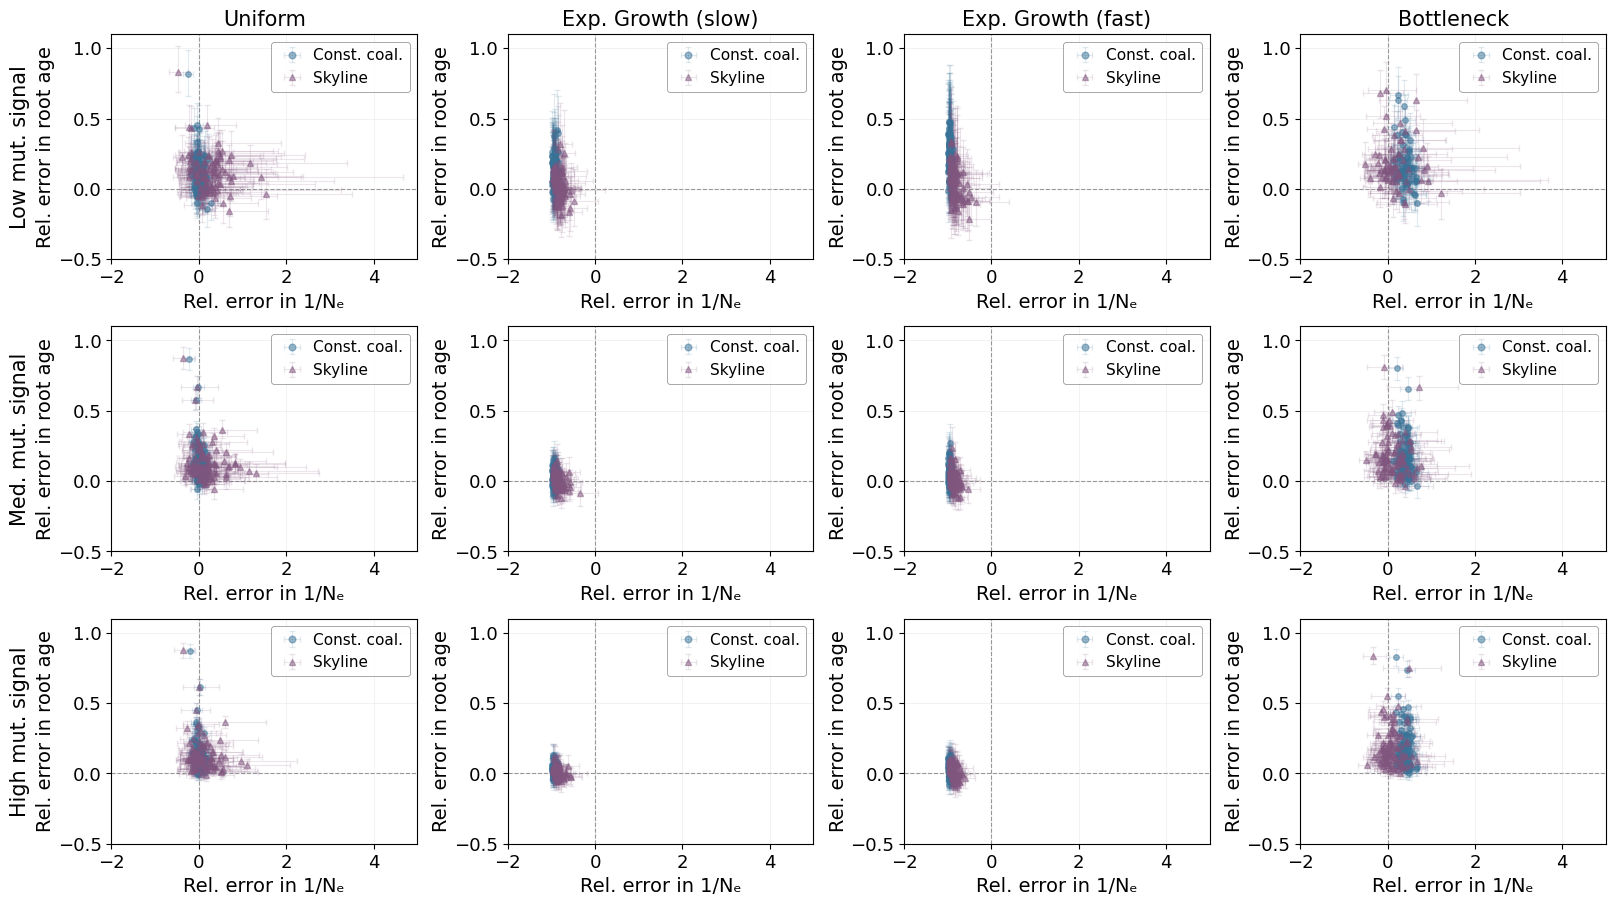

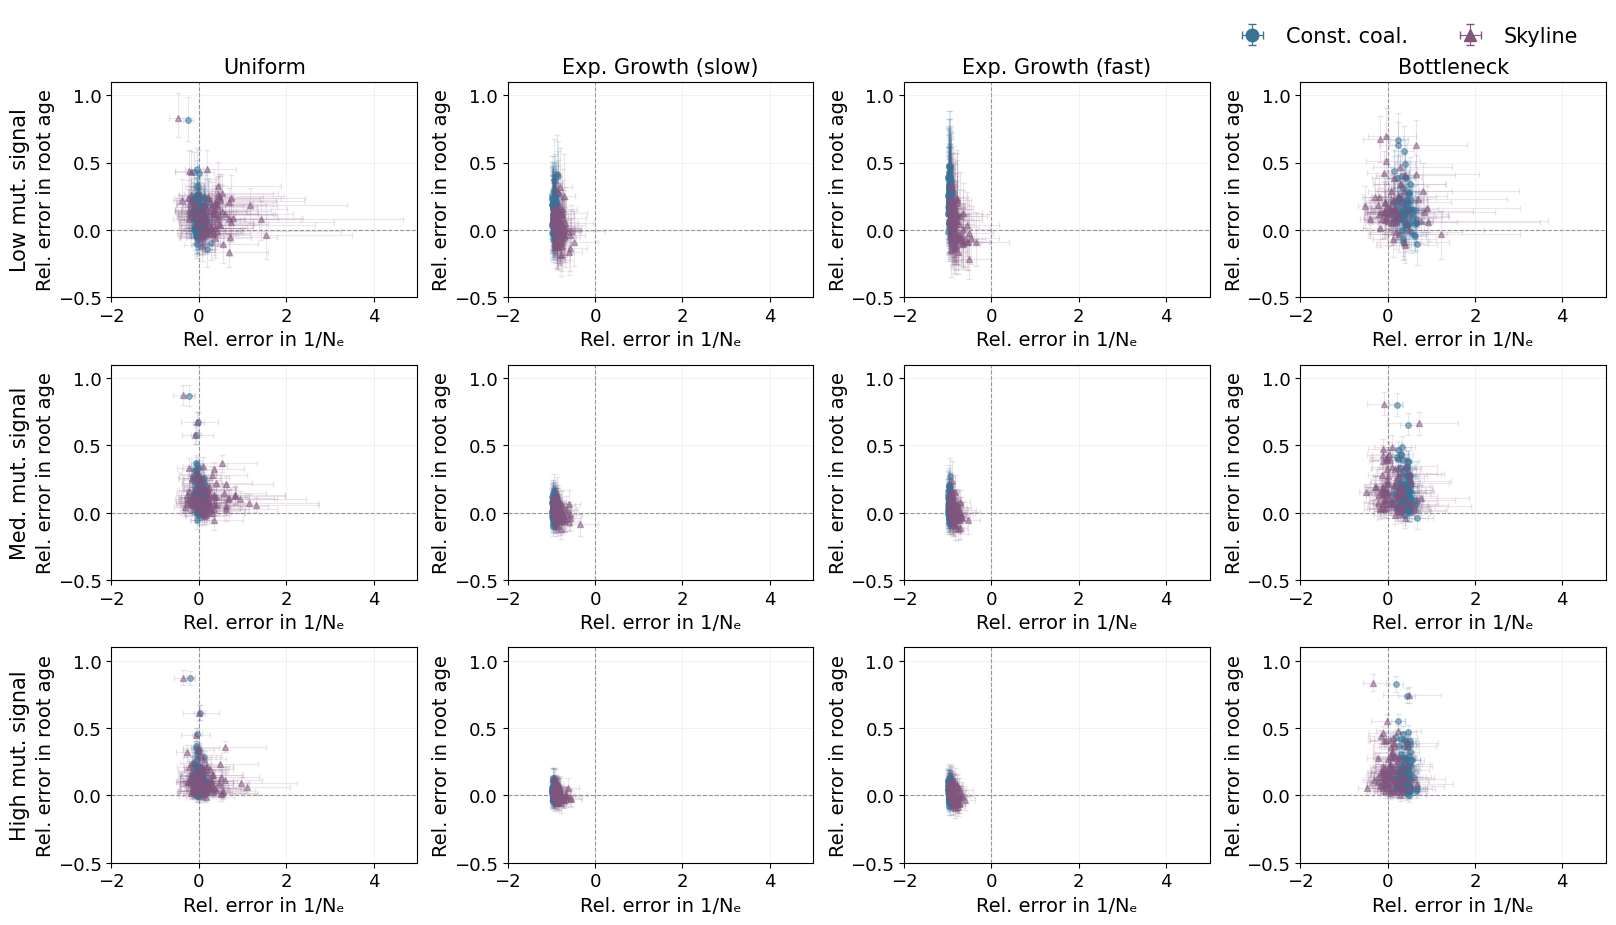

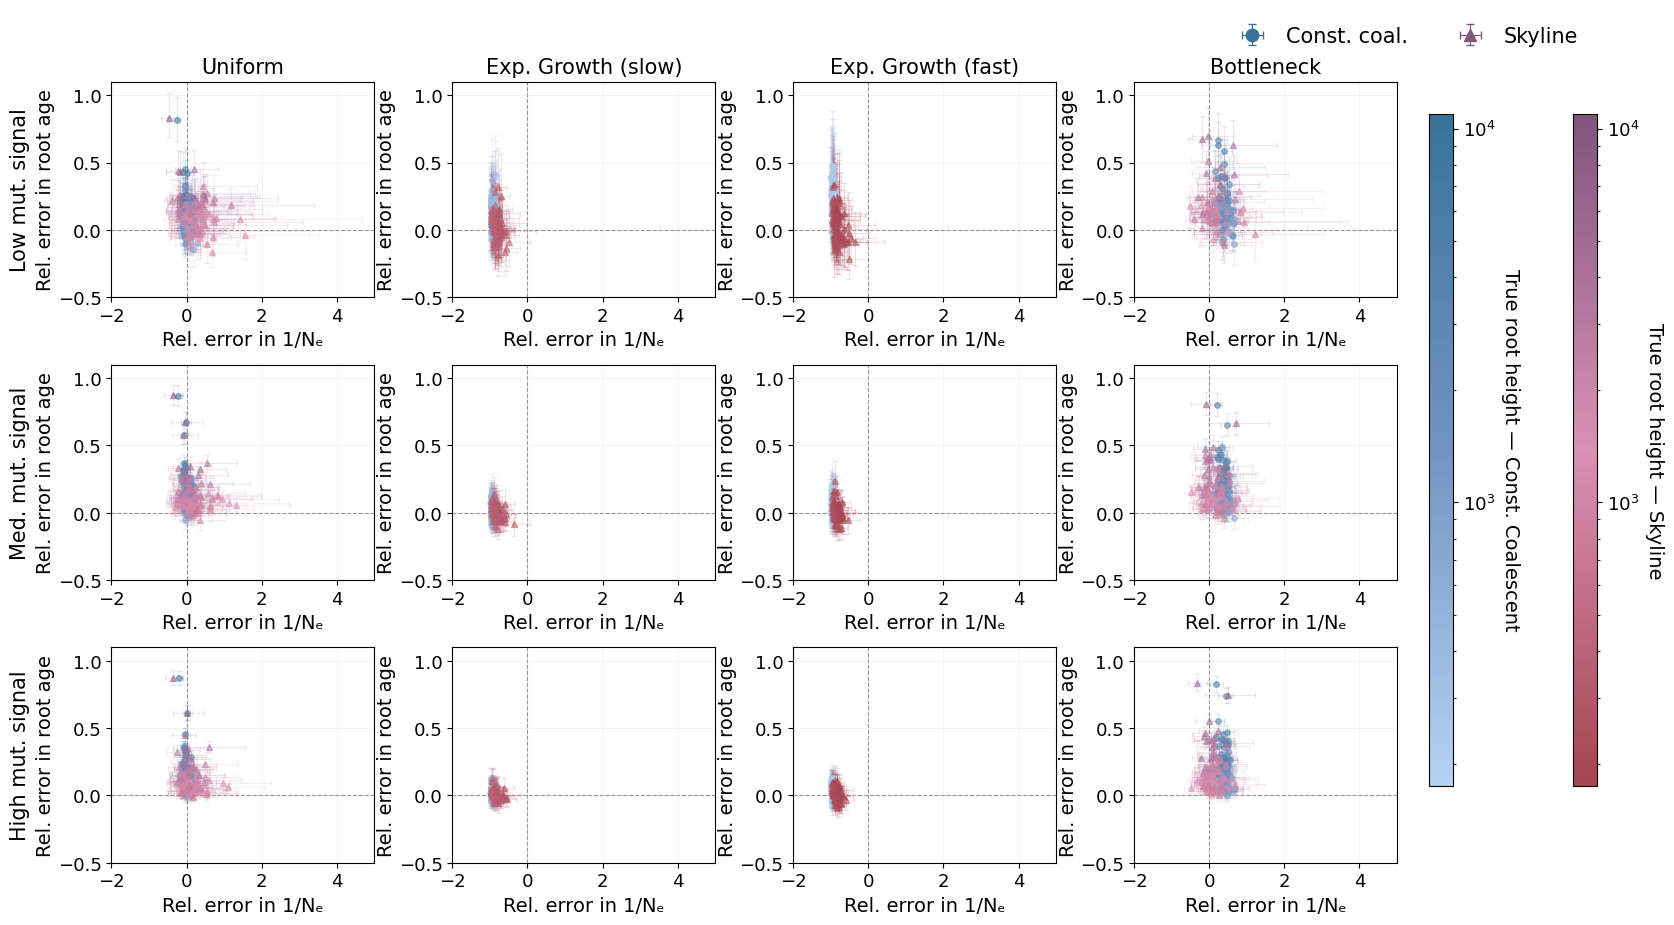

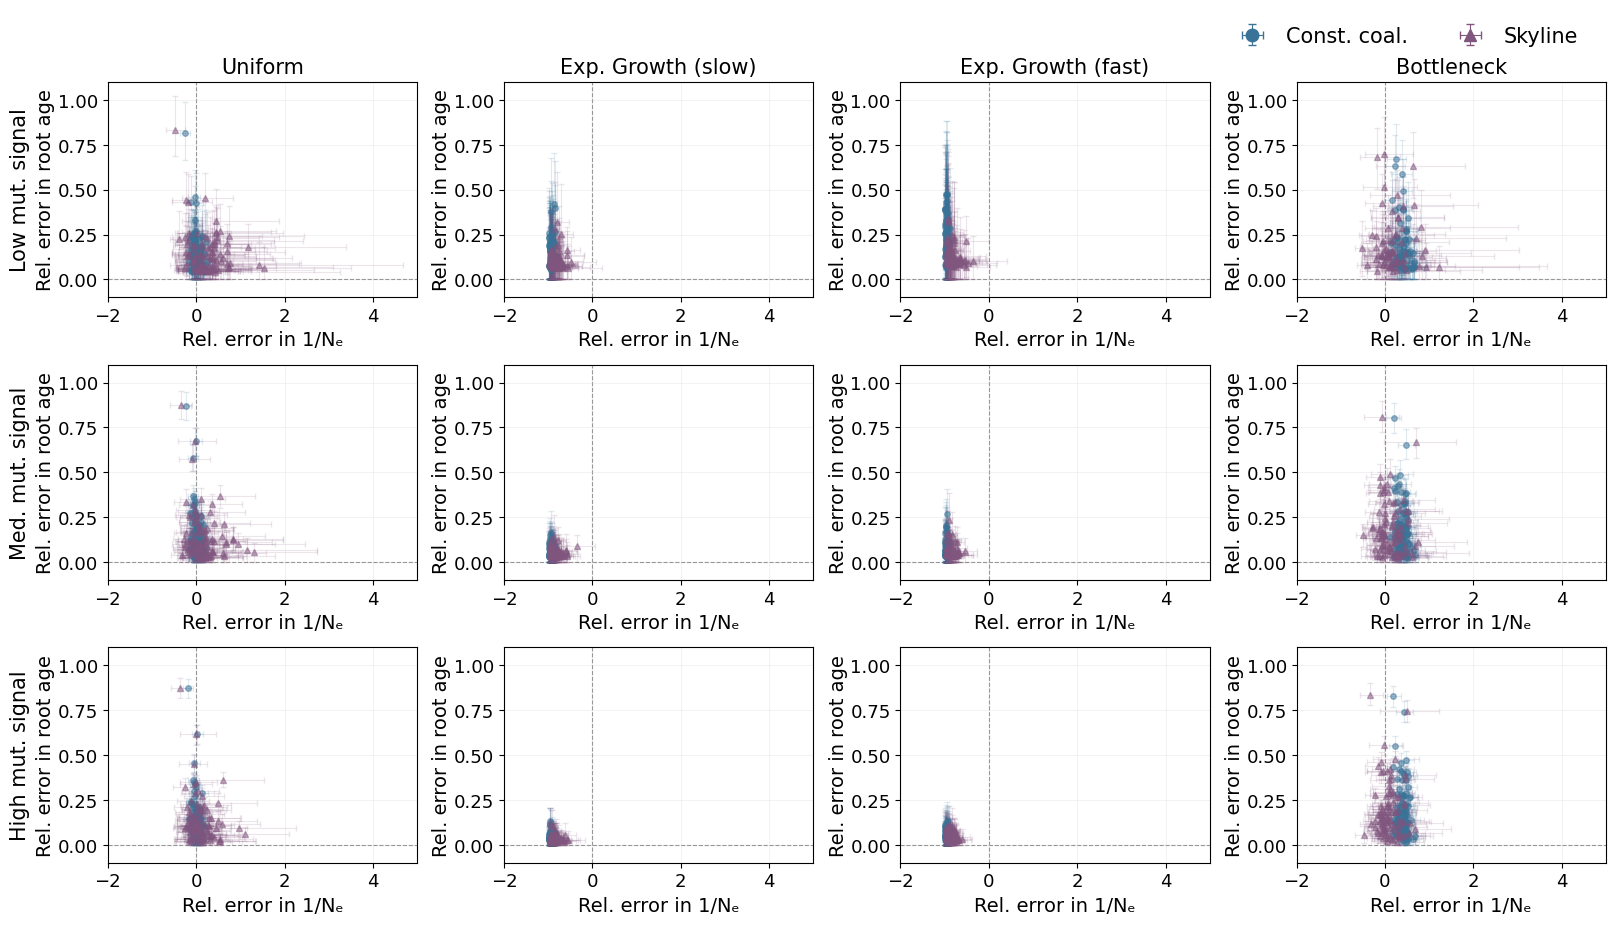

In [7]:
# linearconstant

plot_height_vs_popsize_error(root_height_df_wide, sampling="linearconstant", x_col="rate_rel_error_median", y_col="height_rel_error_median", alpha = 0.5, s = 20, y_range = (-0.5,1.1), x_range = (-2,5), pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'], x_label = "Rel. error in 1/Nₑ", y_label = "Rel. error in root age", title = "", save_path="../figures/root_height/rootheight_rate_error_linearconstant_all_legendin.pdf", legend_inside = True)
plot_height_vs_popsize_error(root_height_df_wide, sampling="linearconstant", x_col="rate_rel_error_median", y_col="height_rel_error_median", alpha = 0.5, s = 20, y_range = (-0.5, 1.1), x_range = (-2,5), pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'], x_label = "Rel. error in 1/Nₑ", y_label = "Rel. error in root age", title = "", save_path="../figures/root_height/rootheight_rate_error_linearconstant_all_legendout.pdf", legend_inside = False)
plot_height_vs_popsize_error(root_height_df_wide, sampling="linearconstant", x_col="rate_rel_error_median", y_col="height_rel_error_median", alpha = 0.5, s = 20, y_range = (-0.5, 1.1), x_range = (-2,5), pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'], x_label = "Rel. error in 1/Nₑ", y_label = "Rel. error in root age", title = "", save_path="../figures/root_height/rootheight_rate_error_linearconstant_all_legendout_timecoloring.pdf", legend_inside = False,
                                color_by_time=True, time_col = "height_sim", log_colorbar=True)

plot_height_vs_popsize_error(root_height_df_wide, sampling="linearconstant", x_col="rate_rel_error_median", y_col="height_abs_rel_error_median", alpha = 0.5, s = 20, y_range = (-0.1, 1.1), x_range = (-2,5), pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'], x_label = "Rel. error in 1/Nₑ", y_label = "Rel. error in root age", title = "", save_path="../figures/root_height/abs_rootheight_rate_error_linearconstant_all_legendout.pdf", legend_inside = False)

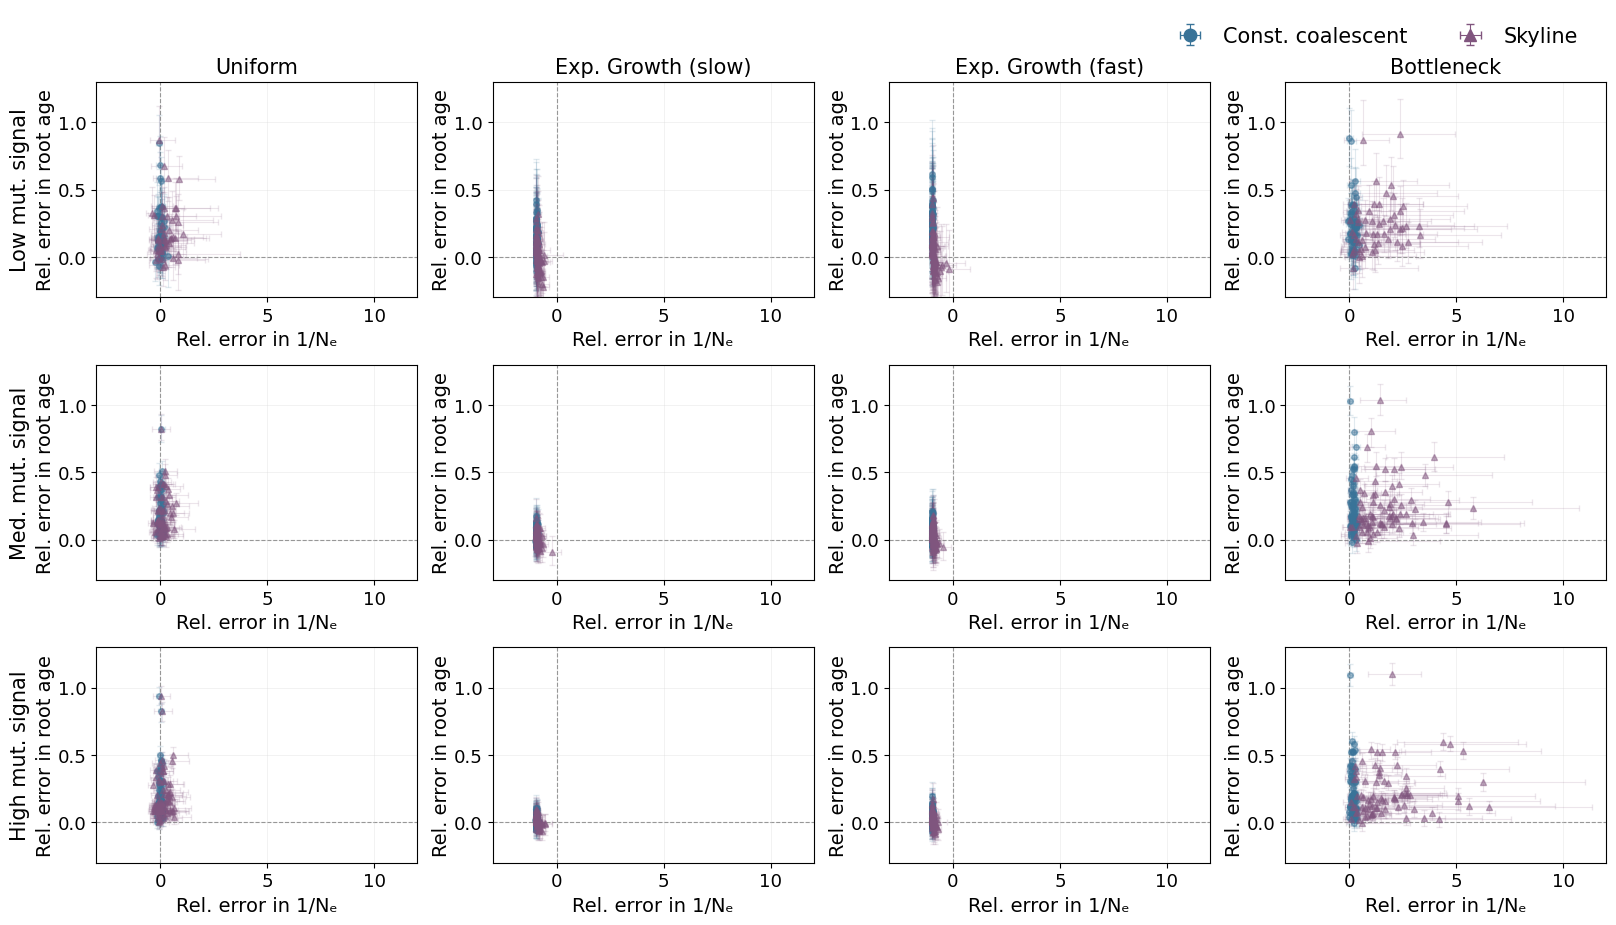

In [9]:
# indepedent homochronous
plot_height_vs_popsize_error(root_height_df_wide, sampling="independenthomochronous", x_col="rate_rel_error_median", y_col="height_rel_error_median", alpha = 0.5, s = 20, x_range = (-3,12), y_range = (-0.3,1.3), pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'], x_label = "Rel. error in 1/Nₑ", y_label = "Rel. error in root age", title = "", save_path="../figures/root_height/rootheight_rate_error_independenthomochronous_all_legendout.pdf", legend_inside = False)

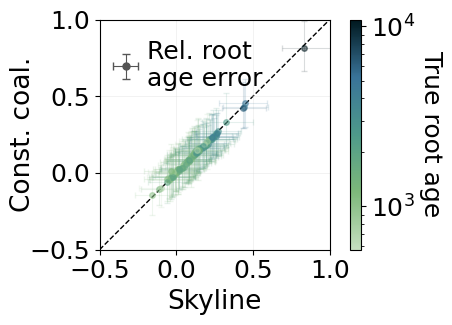

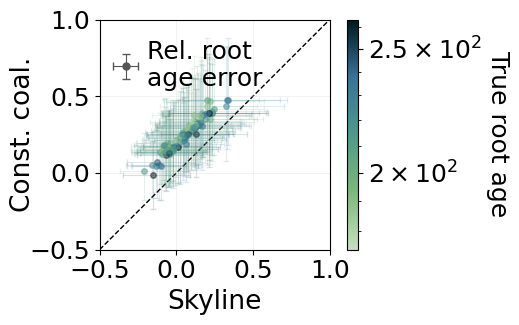

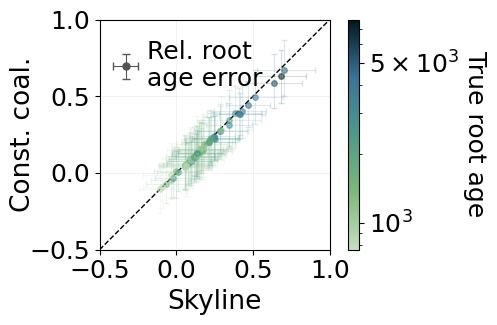

In [3]:
plot_constcoal_vs_skyline_error(root_height_df_wide, sampling="linearconstant",
                                   error_col="height_rel_error_median", error_label = 'Rel. root \n' \
                                   'age error',
                                   x_label="Skyline", y_label="Const. coal.",
                                   x_range = (-0.5, 1), y_range = (-0.5,1), figsize = (6, 3.5),
                                   title = "", label_fontsize=19, tick_fontsize=18, legend_fontsize=18, cbar_tick_fontsize=18,
                                   pop_models = ['uniform'], mutsigs = ['low'], show_pop_model_labels = False, show_mutsig_labels = False,
                                   color_by_time = True, time_col = 'height_sim', log_colorbar = True,
                                   save_path="../figures/root_height/skyline_constcoal_comparison_relrootheighterror_colored_uniform.pdf")

plot_constcoal_vs_skyline_error(root_height_df_wide, sampling="linearconstant",
                                   error_col="height_rel_error_median", error_label = 'Rel. root \n' \
                                   'age error',
                                   x_label="Skyline", y_label="Const. coal.",
                                   x_range = (-0.5, 1), y_range = (-0.5,1), figsize = (6, 3.5),
                                   title = "", label_fontsize=19, tick_fontsize=18, legend_fontsize=18, cbar_tick_fontsize=18,
                                   pop_models = ['expgrowthfast'], mutsigs = ['low'], show_pop_model_labels = False, show_mutsig_labels = False,
                                   color_by_time = True, time_col = 'height_sim', log_colorbar = True,
                                   save_path="../figures/root_height/skyline_constcoal_comparison_relrootheighterror_colored_expgrowthfast.pdf")

plot_constcoal_vs_skyline_error(root_height_df_wide, sampling="linearconstant",
                                   error_col="height_rel_error_median", error_label = 'Rel. root \n' \
                                   'age error',
                                   x_label="Skyline", y_label="Const. coal.",
                                   x_range = (-0.5, 1), y_range = (-0.5,1), figsize = (6, 3.5),
                                   title = "", label_fontsize=19, tick_fontsize=18, legend_fontsize=18, cbar_tick_fontsize=18,
                                   pop_models = ['bottleneck'], mutsigs = ['low'], show_pop_model_labels = False, show_mutsig_labels = False,
                                   color_by_time = True, time_col = 'height_sim', log_colorbar = True,
                                   save_path="../figures/root_height/skyline_constcoal_comparison_relrootheighterror_colored_bottleneck.pdf")

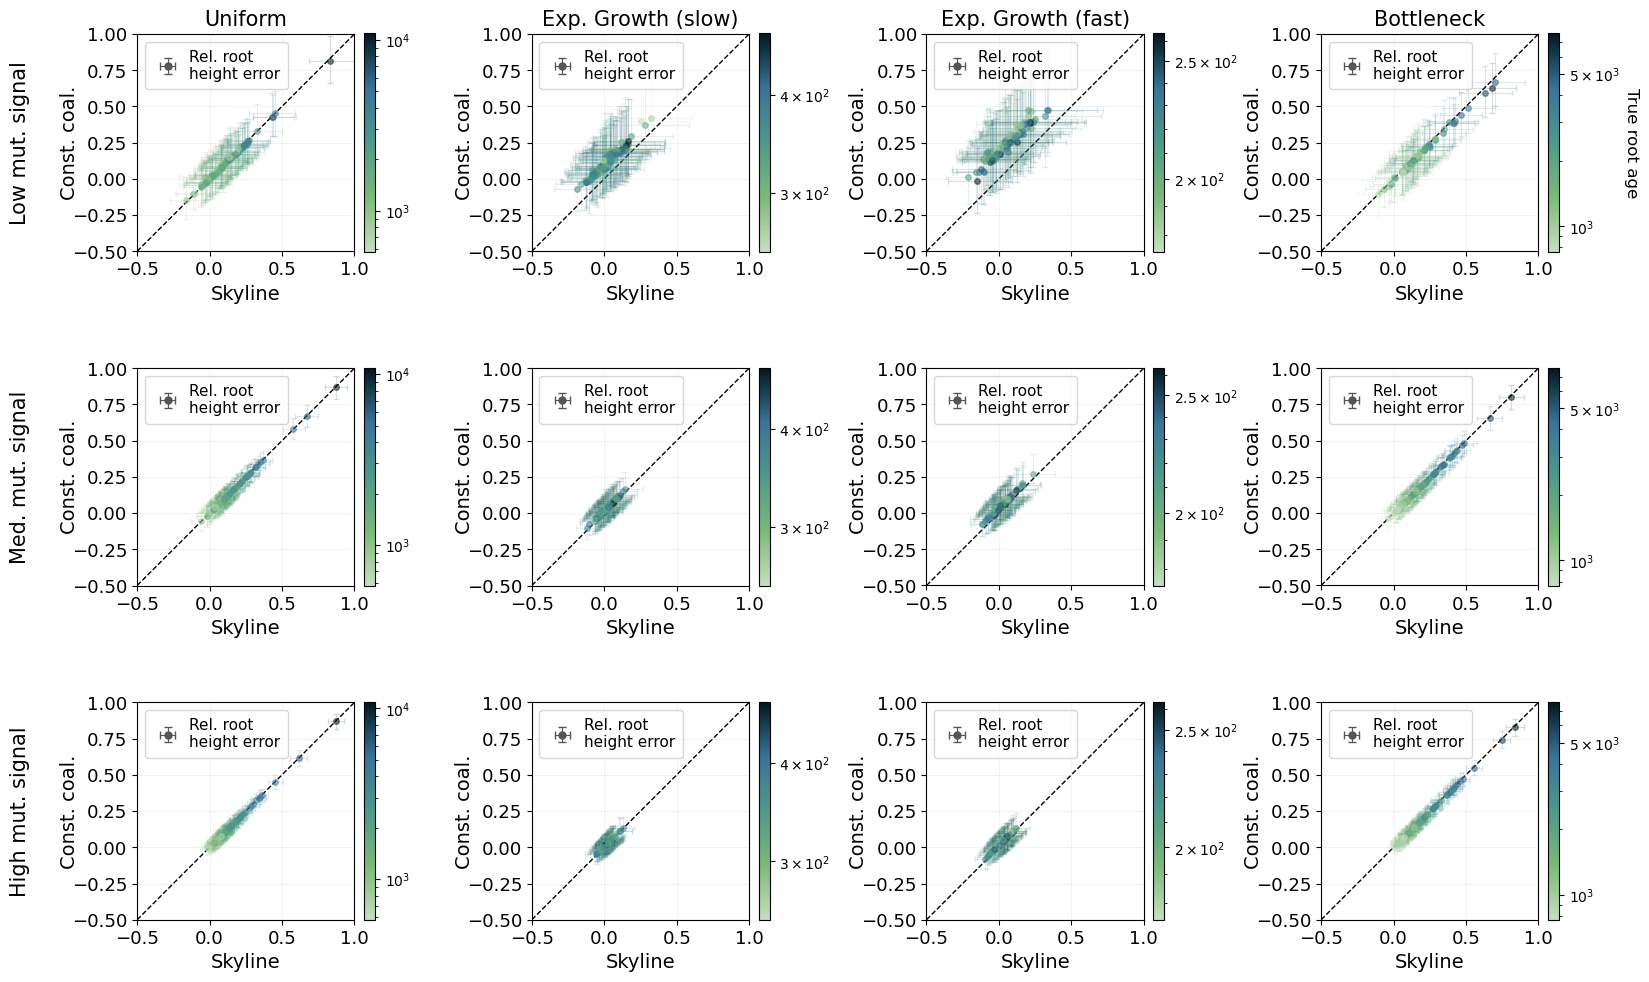

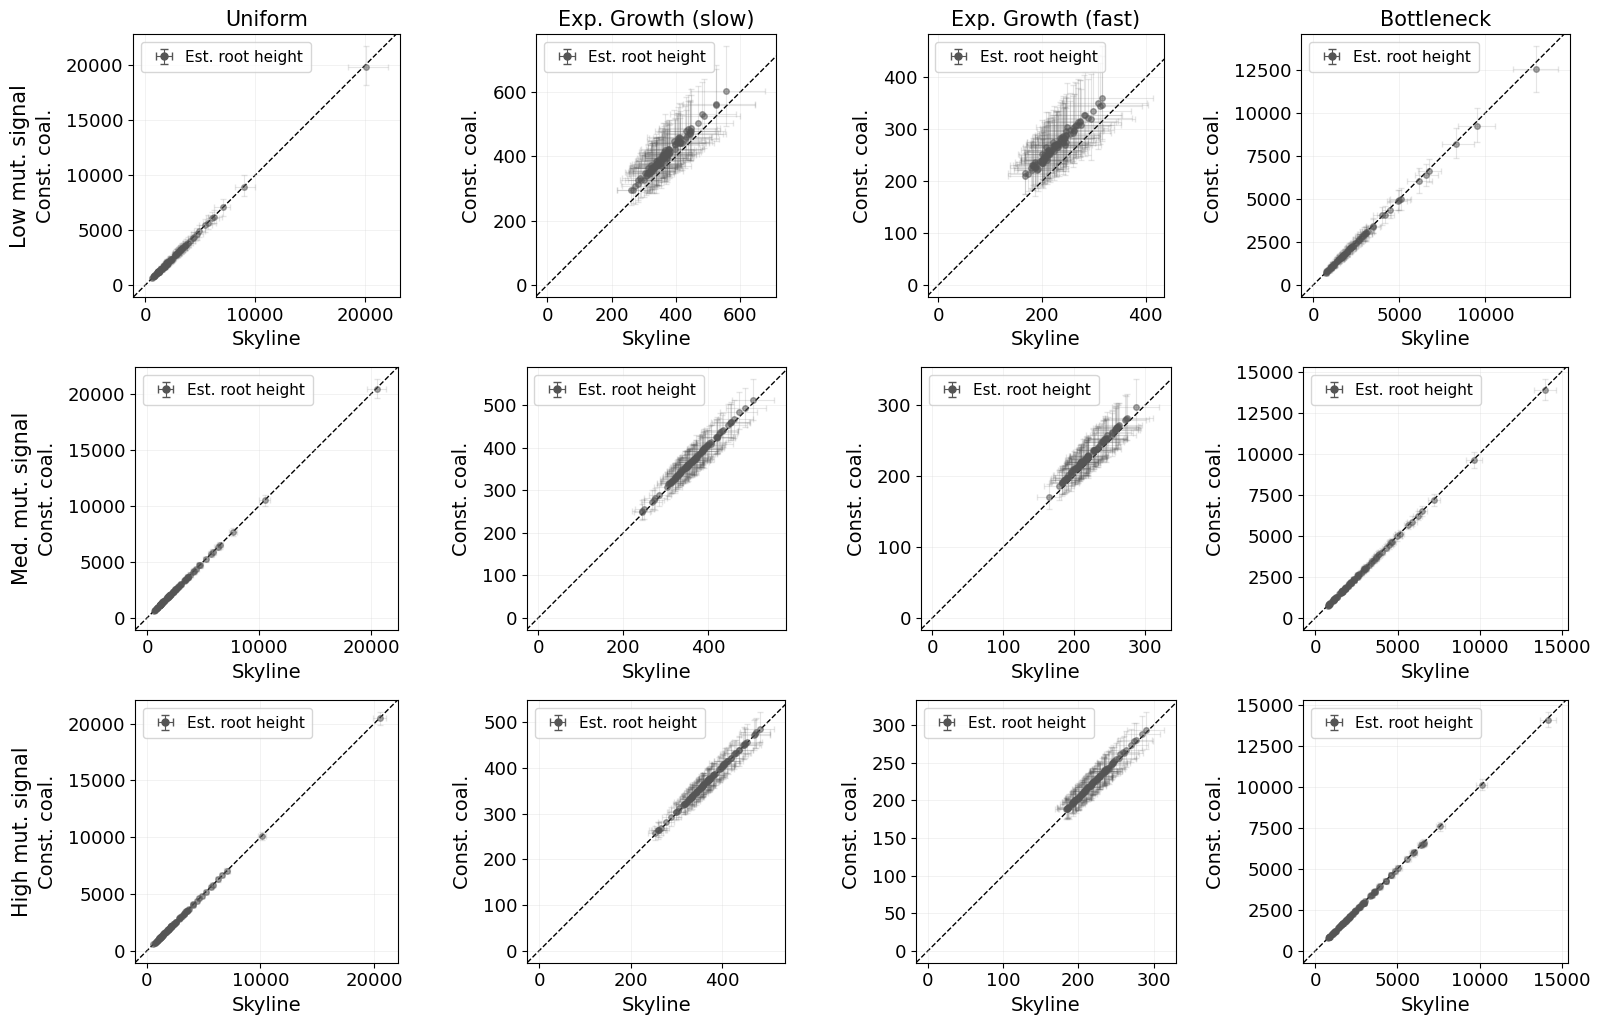

In [5]:
plot_constcoal_vs_skyline_error(root_height_df_wide, sampling="linearconstant",
                                   error_col="height_rel_error_median", error_label = 'Rel. root \n' \
                                   'height error',
                                   x_label="Skyline", y_label="Const. coal.",
                                   x_range = (-0.5, 1), y_range = (-0.5,1),
                                   title = "",
                                   color_by_time = True, time_col = 'height_sim', log_colorbar = True,
                                   save_path="../figures/root_height/skyline_constcoal_comparison_relrootheighterror_colored.pdf")

plot_constcoal_vs_skyline_error(root_height_df_wide, sampling="linearconstant",
                                   error_col="height_est", error_label = 'Est. root height',
                                   x_label="Skyline", y_label="Const. coal.",
                                   x_range = None, y_range = None,
                                   title = "",
                                   save_path="../figures/root_height/skyline_constcoal_comparison_estimatedrootheight.pdf")

## Box plot that summarizes all root heights

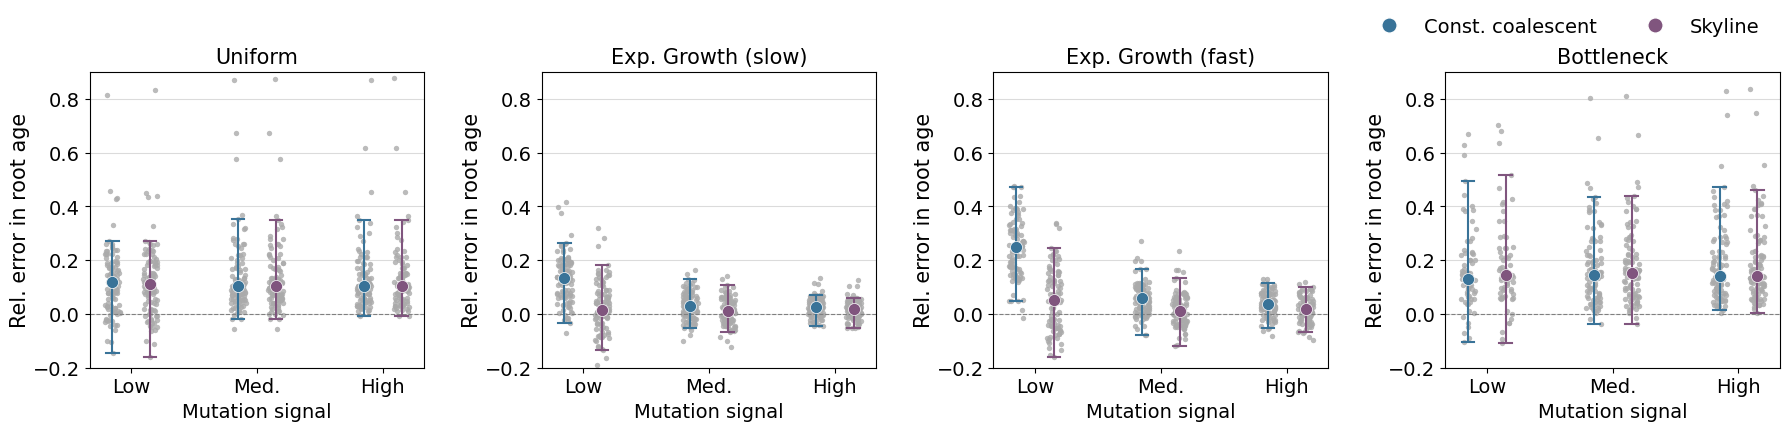

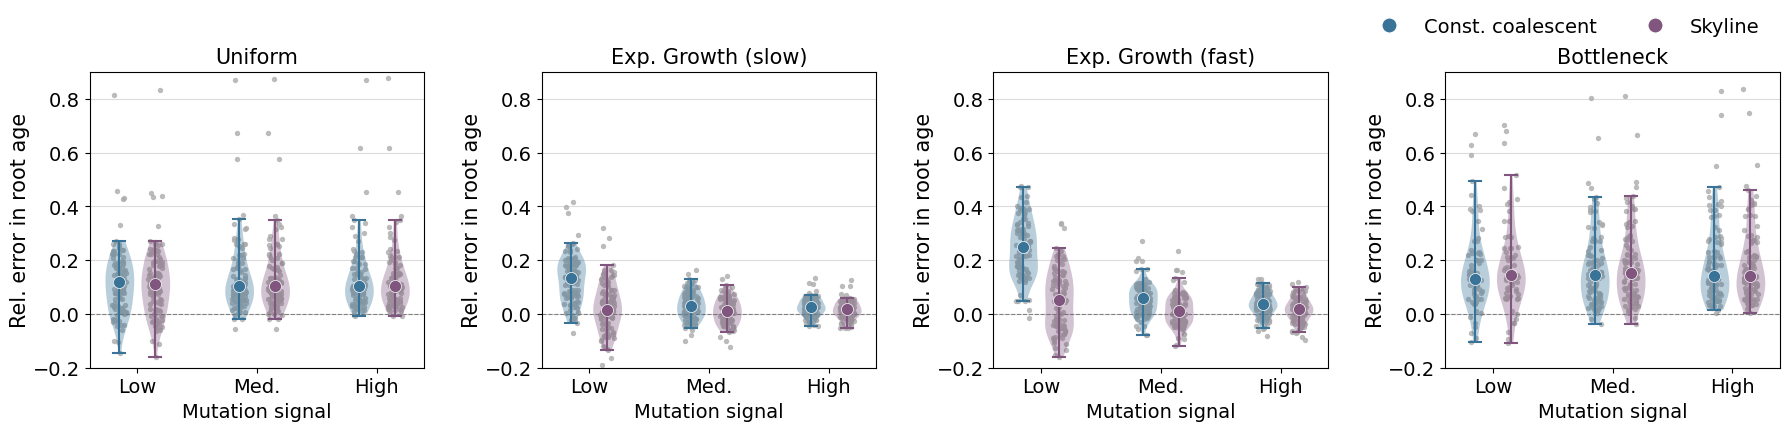

In [3]:
plot_error_by_mutsig(root_height_df_wide, sampling = 'linearconstant',
                        y_col="height_rel_error_median", y_label="Rel. error in root age", y_range=(-0.2, 0.9),
                        pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'],
                        title="", save_path="../figures/root_height/summary_root_error_scatter_linearconstant.pdf")

plot_error_by_mutsig(root_height_df_wide, sampling = 'linearconstant',
                        y_col="height_rel_error_median", y_label="Rel. error in root age", y_range=(-0.2, 0.9),
                        pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'],
                        title="", save_path="../figures/root_height/summary_root_error_scatter_linearconstant_violin.pdf", violin = True)

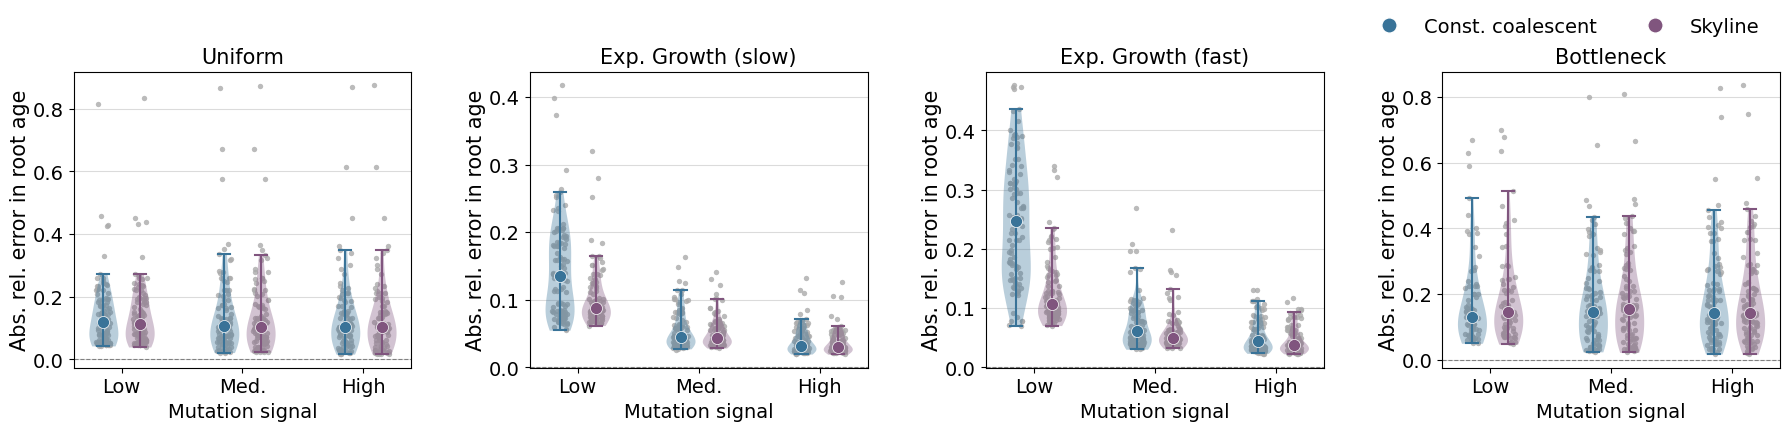

In [4]:
plot_error_by_mutsig(root_height_df_wide, sampling = 'linearconstant',
                        y_col="height_abs_rel_error_median", y_label="Abs. rel. error in root age", y_range=None,
                        pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'],
                        title="", save_path="../figures/root_height/summary_abs_root_error_scatter_linearconstant_violin.pdf", violin = True)

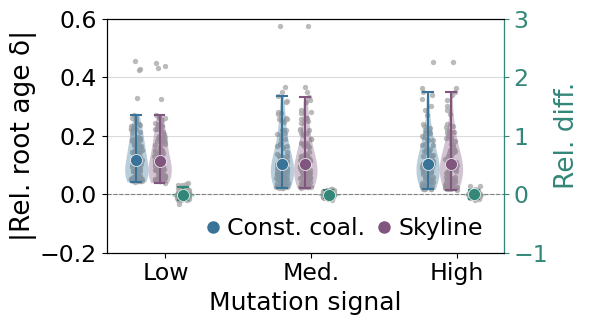

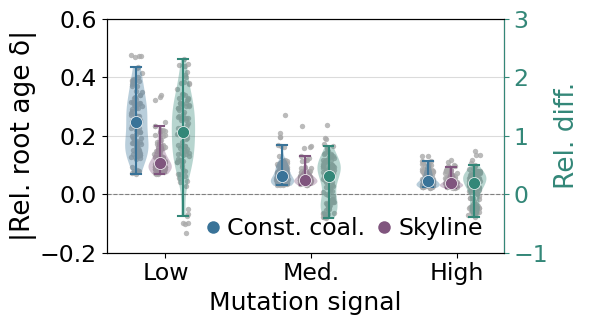

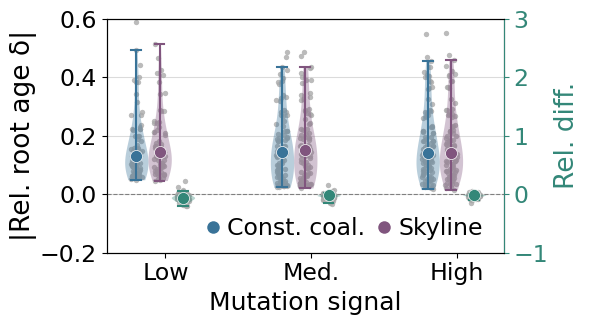

In [4]:
plot_error_by_mutsig(root_height_df_wide, sampling = 'linearconstant',
                        y_col="height_abs_rel_error_median", y_label="|Rel. root age δ|", y_range = (-0.2, 0.6),
                        pop_models=['uniform'], figsize=(6,3.5), legend_inside=True,
                        show_diff=True, diff_mode="relative", diff_y_range = (-1,3),
                        show_pop_model_labels = False, label_fontsize=18, tick_fontsize=17, legend_fontsize=17,
                        title="", save_path="../figures/root_height/summary_abs_root_error_scatter_linearconstant_violin_uniform.pdf", violin = True)

plot_error_by_mutsig(root_height_df_wide, sampling = 'linearconstant',
                        y_col="height_abs_rel_error_median", y_label="|Rel. root age δ|", y_range = (-0.2, 0.6),
                        pop_models=['expgrowthfast'], figsize=(6,3.5), legend_inside=True,
                        show_diff=True, diff_mode="relative", diff_y_range = (-1, 3),
                        show_pop_model_labels = False, label_fontsize=18, tick_fontsize=17, legend_fontsize=17,
                        title="", save_path="../figures/root_height/summary_abs_root_error_scatter_linearconstant_violin_expgrowthfast.pdf", violin = True)

plot_error_by_mutsig(root_height_df_wide, sampling = 'linearconstant',
                        y_col="height_abs_rel_error_median", y_label="|Rel. root age δ|", y_range = (-0.2, 0.6),
                        pop_models=['bottleneck'], figsize=(6,3.5), legend_inside=True,
                        show_diff=True, diff_mode="relative", diff_y_range = (-1, 3),
                        show_pop_model_labels = False, label_fontsize=18, tick_fontsize=17, legend_fontsize=17,
                        title="", save_path="../figures/root_height/summary_abs_root_error_scatter_linearconstant_violin_bottleneck.pdf", violin = True)

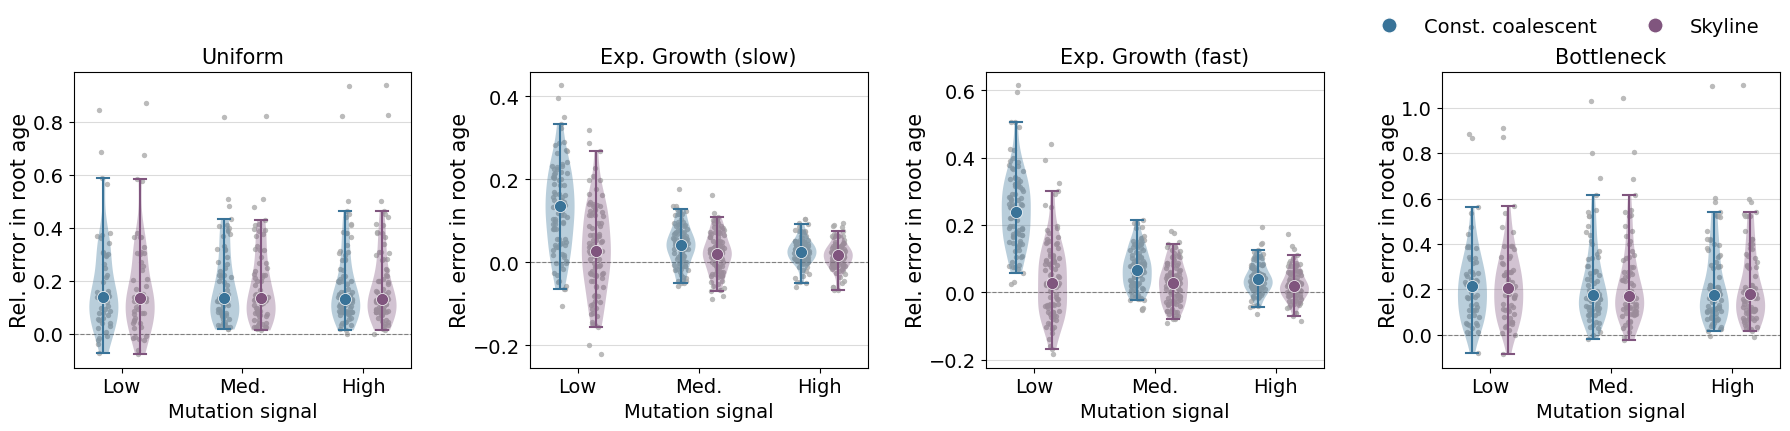

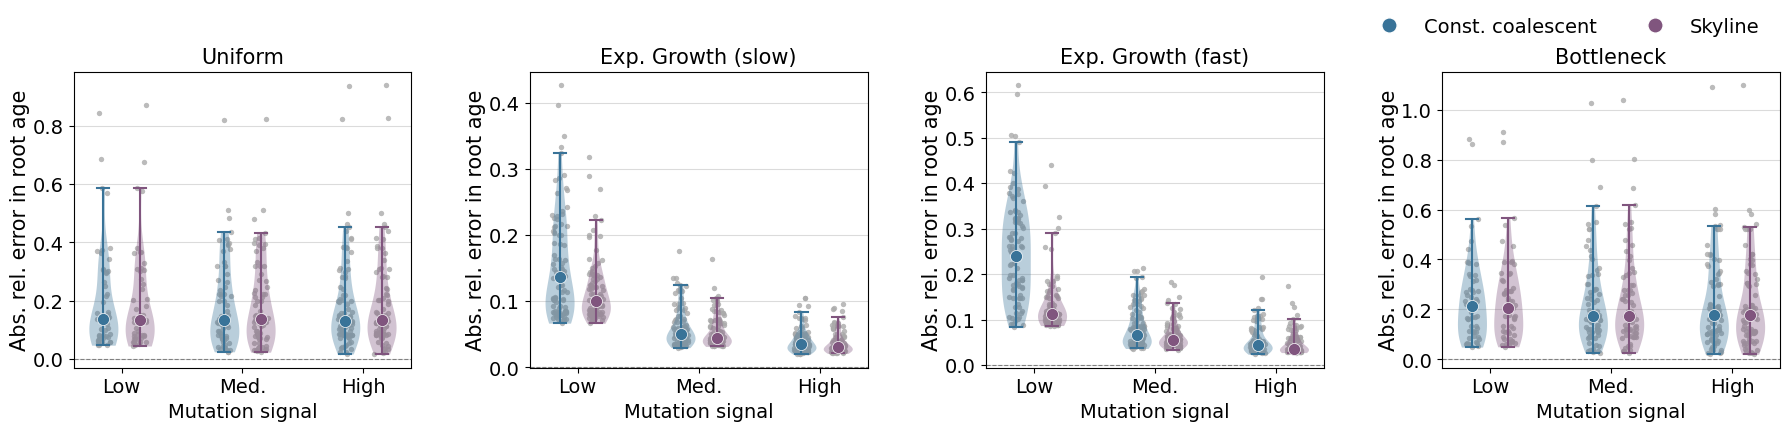

In [5]:
# independent homochronous
plot_error_by_mutsig(root_height_df_wide, sampling = 'independenthomochronous',
                        y_col="height_rel_error_median", y_label="Rel. error in root age", y_range=None,
                        pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'],
                        title="", save_path="../figures/root_height/summary_root_error_scatter_independenthomochronous_violin.pdf", violin = True)

plot_error_by_mutsig(root_height_df_wide, sampling = 'independenthomochronous',
                        y_col="height_abs_rel_error_median", y_label="Abs. rel. error in root age", y_range=None,
                        pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'],
                        title="", save_path="../figures/root_height/summary_abs_root_error_scatter_independenthomochronous_violin.pdf", violin = True)